<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/notebooks/Section05_Computer_Vision/Chapter01_Deep_CNN_Architectures.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**DEEP CNN ARCHITECTURES**

## **Why Depth Matters in Neural Networks**

Back in our discussion on the **Universal Approximation Theorem** in `Section04 - Chapter00`, we saw something surprising: even a shallow neural network with just *one sufficiently large hidden layer* can, in theory, approximate any function. At first glance, this makes depth look unnecessary — if one wide layer can do the job, why complicate things with many?

The answer lies in **practice, not theory**. While shallow networks *can* represent complex mappings, they require an explosion of parameters, making them inefficient, slow to train, and prone to overfitting. In contrast, **deeper networks** learn *hierarchically*: each layer captures increasingly abstract features, building complexity step by step. This structured learning is not just more natural — it’s more powerful.

---

### **The Power of Small Filters**

Let’s look at this through the lens of **Convolutional Neural Networks (CNNs)**. Suppose you want your network to “see” patterns across a \$7 \times 7\$ region of an image.

* A **single $7 \times 7$ filter** directly covers this region, but it requires $C \times (7 \times 7 \times C) = 49C^2$ parameters per filter (where $C$ is the number of channels). That’s costly.
* Now consider **three stacked $3 \times 3$ filters**. Together, they cover the same $7 \times 7$ region — but only need $3 \times [C \times (3 \times 3 \times C)] = 27C^2$ parameters. That’s nearly half the cost, while giving us *three layers of representation* instead of one.

And the benefits don’t stop at parameter savings:

* **Hierarchical Feature Learning**: The first $3 \times 3$ filter may detect edges, the second might detect corners or curves, and the third could assemble those into textures or object parts. This layered progression mimics how the human visual system works — from simple photoreceptors to complex object recognition. A single layer no matter how wide, on the other hand, might only detect the edges and that's it.
* **More Non-Linear Power**: Between filters, we insert activation functions (like ReLU). Stacking layers means multiple non-linear transformations, allowing the network to model far richer relationships than one wide layer ever could.

* **Efficiency & Regularization**: With fewer parameters, the model trains faster and is less likely to overfit. And notice — we haven’t even brought **pooling layers** into the picture yet. Now imagine stacking them between convolutional layers: each pooling step drastically reduces the number of parameters while amplifying the most important features. By designing deeper architectures, we give more pooling layers the chance to contribute, gradually shrinking massive inputs into compact, information-rich representations. In contrast, a shallow network with one or two wide layers would end up with only a few coarse, almost “blurry” features — far less useful for understanding the richness of real-world images.

## **The Depth Separation Theorem**

To understand *why* depth is such a game-changer in neural networks, we turn to the **Depth Separation Theorem**, introduced by Matus Telgarsky in his 2016 paper, [Benefits of Depth in Neural Networks](https://arxiv.org/abs/1602.04485).  

The theorem proves something striking:  
> A deep network can represent certain functions with **exponentially fewer neurons** than a shallow one.  

In plain words: for some patterns, a shallow network would need a *huge* number of neurons, while a deeper network can build the same function step by step with far fewer resources.  

---

### **The Intuition**

Think of data that has a **hierarchical structure**:  
- Simple details (edges, lines) combine into…  
- Intermediate patterns (corners, textures)…  
- Which finally form complex objects (faces, animals, etc).  

A shallow network must learn all of this *at once*. It’s like trying to write an entire book in one sentence. A deeper network, however, handles it chapter by chapter: edges first, then textures, then shapes — reusing earlier results along the way.  

---

### **Numbers That Make It Real**

Telgarsky showed mathematically:  

- A shallow network with $k$ layers might need on the order of **$2^k$ neurons** to represent certain “zigzag” or oscillating functions.  
- A deeper network with more layers can do the same job with only **linear growth in neurons** (something like $O(d)$ per layer).  

That’s the exponential savings: depth beats width.  

Imagine training a CNN to recognize cats in photos.  

- **Shallow CNN (1 Conv Layer)**  
  To directly capture hundreds of edge directions, textures, and shapes, you’d need a massive number of filters in one layer — thousands of parameters, prone to overfitting.  

- **Deep CNN (4 Conv Layers)**  
  Instead of brute-forcing everything at once, the first layer finds edges, the second combines them into corners and curves, the third forms textures, and the fourth recognizes object parts. By stacking layers, the network reuses features instead of relearning them from scratch. The total parameters remain far lower, yet the expressive power is higher.  

This matches Telgarsky’s proof: deeper networks are not just “a little better,” they’re *exponentially more efficient*.  

As we move into landmark architectures like **AlexNet (2012)** which shocked the world by stacking eight layers and crushed shallow competitors on ImageNet and later **ResNet (2015)** that went even further, proving that networks dozens — even hundreds — of layers deep could not only train successfully but outperform shallower ones by a huge margin, remember: their success rests on this very principle — that depth unlocks efficiency and intelligence in a way shallow networks never could.


##**AlexNet**

In computer vision history, **AlexNet** is remembered as the architecture that ignited the *deep learning revolution*. Introduced in the 2012 paper, [ImageNet Classification with Deep Convolutional Neural Networks](https://papers.nips.cc/paper_files/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html) by *Alex Krizhevsky, Ilya Sutskever, and Geoffrey Hinton*, AlexNet proved that **deep CNNs + massive data + GPU power** could completely outperform traditional computer vision approaches.  

Before AlexNet, most image recognition relied on **handcrafted features** (like SIFT or HOG) combined with shallow classifiers (like SVMs). These worked decently on small datasets (e.g., Caltech-101 with 9k images or CIFAR-10 with 60k images) but fell short for real-world variation in **scale, pose, and lighting**. Neural networks were known in theory to be good at images (because of *locality* and *translation invariance*), but the computational power just wasn’t there. But they all changed in 2012.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C01/alexnet.png" width="700">
  <h6>Figure 0: AlexNet architecture</h6>
</div>

**Image Credit:** [Original Paper](https://papers.nips.cc/paper_files/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html)

### **Why AlexNet Was a Breakthrough**

The brilliance of AlexNet was not in inventing CNNs — those already existed — but in showing that they *could scale*. AlexNet had **60 million parameters**, something considered impossible before, and was successfully trained on high-resolution images by fully harnessing **GPUs**.  

Some of its innovations that became standard practice include:  
- **ReLU activations** → faster convergence than tanh or sigmoid.  
- **Dropout regularization** → prevented overfitting despite the model’s size.  
- **Data augmentation** → image translations, reflections, and crops to expand training data.  
- **Multi-GPU training** → parallelization to handle the huge computation (we will cover them all in full detail in a bit).

And the results? AlexNet **crushed** the ImageNet Large Scale Visual Recognition Challenge (ILSVRC) 2012:  
- Previous best *top-5 error*: **26%**  
- AlexNet’s *top-5 error*: **15.3%**  

This 10% leap wasn’t just an improvement — it was a paradigm shift that proved *depth + data + GPUs* beats handcrafted pipelines.  

---

## **The ImageNet Dataset**

AlexNet’s success was inseparable from the dataset it trained on: the **ImageNet Large Scale Visual Recognition Challenge (ILSVRC)**, a curated subset of the [ImageNet dataset](https://www.kaggle.com/datasets/dimensi0n/imagenet-256).  

The scale was unprecedented:  
- **Training set**: ~1.2 million images  
- **Validation set**: 50,000 images  
- **Test set**: 150,000 images (labels withheld for competition)  

With **1,000 categories**, each having around 1,000 examples, the dataset provided the diversity needed for the network to learn **hierarchical features** — from edges, to textures, to whole objects.  

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C01/imagenet.png" width="500">
  <h6>Figure 1: Some of the images in the ImageNet dataset</h6>
</div>

**Image Credit:** [Original Website](https://www.kaggle.com/datasets/dimensi0n/imagenet-256)

AlexNet was more than just a model — it was the **proof of concept** that deep learning could finally scale, and it lit the spark for everything that came after: VGG, GoogLeNet, ResNet, and beyond.

### **Layer by Layer Architecture**

AlexNet has **8 learned layers** (5 convolutional + 3 fully connected), totaling about **60 million parameters** and **650,000 neurons**. It processes an RGB input of **224×224×3** and outputs class probabilities for **1,000 categories** via softmax.  

To train such a large network, AlexNet was cleverly **split across two GPUs**, with cross-connections only where needed to minimize communication. Below is the layer-by-layer flow:  

---

#### **1. Input Layer**
- Input: 224×224×3 RGB image (after preprocessing).  

---

#### **2. Convolutional Layer 1 (Conv1)**
- 96 filters of size 11×11×3, stride 4, padding 1.  
- Activation: **ReLU**.  
- Followed by **Local Response Normalization (LRN)**.  
- Output: 55×55×96.  
- **Max Pooling (Pool1)**: 3×3 kernel, stride 2 (overlapping).  

---

#### **3. Convolutional Layer 2 (Conv2)**
- 256 filters of size 5×5×48 (split across 2 GPUs).  
- Stride 1, padding 2.  
- Activation: ReLU + LRN.  
- Output: 27×27×256.  
- **Max Pooling (Pool2)**: 3×3 kernel, stride 2.  

---

#### **4. Convolutional Layer 3 (Conv3)**
- 384 filters of size 3×3×256 (connected to all Conv2 maps).  
- Stride 1, padding 1.  
- Activation: ReLU.  
- Output: 13×13×384.  

---

#### **5. Convolutional Layer 4 (Conv4)**
- 384 filters of size 3×3×192 (split across GPUs).  
- Stride 1, padding 1.  
- Activation: ReLU.  
- Output: 13×13×384.  

---

#### **6. Convolutional Layer 5 (Conv5)**
- 256 filters of size 3×3×192 (split across GPUs).  
- Stride 1, padding 1.  
- Activation: ReLU.  
- Output: 13×13×256.  
- **Max Pooling (Pool5)**: 3×3 kernel, stride 2 → 6×6×256.  

---

#### **7. Fully Connected Layer 6 (FC6)**
- 4096 neurons.  
- Activation: ReLU.  
- **Dropout (p=0.5)**.  
- Input size: 9216 (flattened from Pool5).  

---

#### **8. Fully Connected Layer 7 (FC7)**
- 4096 neurons.  
- Activation: ReLU.  
- Dropout (p=0.5).  

---

#### **9. Fully Connected Layer 8 (FC8) / Output**
- 1000 neurons (one per class).  
- **Softmax** activation for probabilities.  

---

###**Key Design Choices and Innovations**

The paper meticulously justifies each element to address challenges like overfitting, slow training, and hardware limits:  

- **Two Parallel Paths (Multi-GPU Training)**: Limited by NVIDIA GTX 580 GPUs (3GB each), the network is duplicated across two GPUs. Layers like Conv2, Conv4, and Conv5 connect only to kernel maps on the same GPU, while Conv3 and fully connected layers allow cross-GPU communication. This halved training time (to 5-6 days) and improved error rates by 1.7% (top-1) and 1.2% (top-5) compared to a single-GPU version, as the split encouraged diverse feature learning.

- **ReLU Activation**: Chosen over saturating functions like Tanh or Sigmoid because ReLU $f(x) = \text {max}(0, x)$ doesn't saturate in the positive domain, enabling faster gradient flow. On CIFAR-10, a ReLU CNN reached 25% error in 6x fewer epochs than Tanh. This was crucial for training deep nets without vanishing gradients.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C01/relu_tanh.png" width="300">
  <div>Figure 2: A four-layer CNN with ReLUs (solid line) reaches a 25% training error rate on CIFAR-10 <br> 6 times faster than an equivalent network with Tanh neurons (dashed line)</div>
  <div><strong>Image Credit: </strong><a href="https://papers.nips.cc/paper_files/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html">Original Paper</a></div>
</div>

- **Dropout Regularization**: Applied to FC6 and FC7 ($p=0.5$), it randomly sets half the neurons to zero during training, forcing the network to learn redundant representations and reducing co-adaptation. This halved test error rates, though it doubled training iterations needed for convergence.

- **SGD with Momentum**: Used for optimization with batch size 128, momentum 0.9, weight decay 0.0005 (as L2 regularization), and initial learning rate 0.01 (halved when validation error plateaued). Momentum helped navigate the loss landscape, and weight decay prevented large weights, aiding generalization.

- **Local Response Normalization (LRN)**: This technique is used after the **ReLU** activation in the **Conv1** and **Conv2** layers of a neural network. It helps by normalizing the activity across nearby channels, making the network work better with different types of data. The formula looks like this:  
$$
b_{x,y}^i = \frac {a_{x,y}^i}{\left(k + \alpha \sum_{j=\max(0,i-n/2)}^{\min(N-1,i+n/2)} (a_{x,y}^j)^2 \right)^\beta}
$$  
    - $a_{x,y}^i$ is the original value at position $(x, y)$ in channel $i$ after **ReLU**.
    - $b_{x,y}^i$ is the new, normalized value for that spot.
    - The division adjusts each value based on the sum of squared values from nearby channels (within a range of $n/2$ channels around $i$).
    - The constants are set as $k=2$, $n=5$, $\alpha=10^{-4}$, and $\beta=0.75$, which control how strong the normalization is. This process is inspired by how our brains work—called **lateral inhibition**—where some neurons slow down others nearby to make certain features stand out. In the network, LRN helps by encouraging competition among neurons, which makes the model better at generalizing (handling new data well). Tests show it improves results by 1.4% for top-1 accuracy and 1.2% for top-5 accuracy, meaning it helps the model pick the right answer more often.

- **Overlapping Max Pooling**: Uses 3×3 pools with stride 2 (overlapping by 1), outperforming non-overlapping (stride=pool size) by 0.4% top-1 and 0.3% top-5. Overlap captures more spatial info, reducing overfitting.

- **Data Augmentation**: To combat overfitting on 1.2M images (still limited for 60M parameters), the authors used data augmentation: random 224×224 crops/flips from 256×256 images (2048x gain), and PCA-based color jittering (altering RGB intensities, reducing top-1 error by >1%). This artificially expanded the dataset 2048-fold without extra collection. (More on it soon in this chapter)

###**Other notes:**  
- ~60M parameters (mostly in fully connected layers).  
- Training took ~90 cycles (5–6 days) on two GTX 580 GPUs.  
- No unsupervised pre-training — only labeled data was used.  

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C01/alexnet_results.png" width="400">
  <h6>Figure 3: A sample of AlexNet test results</h6>
</div>

**Image Credit:** [Original Paper](https://papers.nips.cc/paper_files/paper/2012/hash/c399862d3b9d6b76c8436e924a68c45b-Abstract.html)

###**Data Augmentation**

In machine learning, overfitting often occurs when a model has far more parameters than the available training data points, allowing it to memorize noise or specifics rather than learning general patterns. For instance, imagine training a simple classifier with over 1,000 parameters on just 10 data samples—it's like asking a student to learn topics in an entire textbook from a single page; the model will overfit to those exact samples and fail on new ones. In contrast, AlexNet's 60 million parameters don't inherently cause overfitting and the reason is that it's trained on a massive dataset like ImageNet (~1.2 million images), providing enough variety to learn meaningful features. However, even large datasets can feel "limited" for deep models if they lack diversity in poses, lighting, or angles, leading to poor generalization.

This is where **data augmentation** comes in—a clever technique to artificially expand your dataset by creating modified versions of existing samples, all while preserving the original data distribution and labels. The goal isn't to fabricate entirely new data from scratch but to generate variations that mimic real-world diversity, helping the model learn robust patterns without collecting more raw data (which can be expensive or even impossible).

---

###**Why Data Augmentation Helps Combat Overfitting**

With a small or repetitive dataset, models struggle to capture true underlying patterns. Consider a cat-vs-dog classifier trained on just two images: a photo of a cat and one of a dog. The model might latch onto irrelevant details—like the background color or the animal's exact pose—rather than learning that cats have pointy ears and whiskers while dogs often have floppy ears and broader snouts. Result? It overfits to those two images and misclassifies a lot of unseen images.

Data augmentation addresses this by transforming the original images in ways that don't alter their meaning. To the human eye, these changes are so small, but to the model, each variation is a "new" example, enriching the training set and encouraging invariance to minor changes like rotation or lighting.

---

###**How Data Augmentation Works for Images**

For image data, **data augmentation** uses transformations like rotation, flipping, cropping, color adjustments, and noise addition to create new training examples. These changes are applied randomly during training (e.g., using PyTorch's `transforms` or TensorFlow's `ImageDataGenerator`) to keep the model exposed to variety without pre-generating a fixed set. The goal is to enhance robustness while preserving the original label's meaning.

But keep in mind that not all techniques fit every dataset—wrong choices can skew the data distribution. For example:
- **Animal Recognition (e.g., Dogs)**: Rotation and cropping work, but avoid drastic color changes like turning a dog green gives a biased inaccurate data.
- **Fruit Classification**: Color adjustments suit ripening (e.g., green to red apples), while rotation may not be so useful for round fruits.
- **Medical Imaging (e.g., X-Rays)**: Change brightness or add noises, but rotations or flips would change the meaning, and skip color changes since X-rays are grayscale.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C01/augmentation.png" width="600">
</div>

**Image Credit:** [Original Website](https://ubiai.tools/what-are-the-advantages-anddisadvantages-of-data-augmentation-2023-update/)

The key is to match augmentation to the data’s natural variations.

For non-image data, techniques differ entirely:
- **Text Data**: Synonym replacement (e.g., "happy" → "joyful"), back-translation (translate to another language and back), or sentence shuffling. Avoid random word flips, as they could change meaning.
- **Audio Data**: Time-stretching (speed up/slow down speech), pitch shifting, or adding background noise (e.g., crowd sounds for voice recognition). Rotation doesn't apply here.
- **Tabular Data**: SMOTE (Synthetic Minority Over-sampling Technique) for imbalanced classes, or adding Gaussian noise to numerical features.

In essence, data augmentation is like giving your model "virtual experiences" to broaden its worldview without real-world costs. It was pivotal in AlexNet's success, boosting effective dataset size by factors of thousands.

In [ ]:
import torch
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import urllib.request
from io import BytesIO

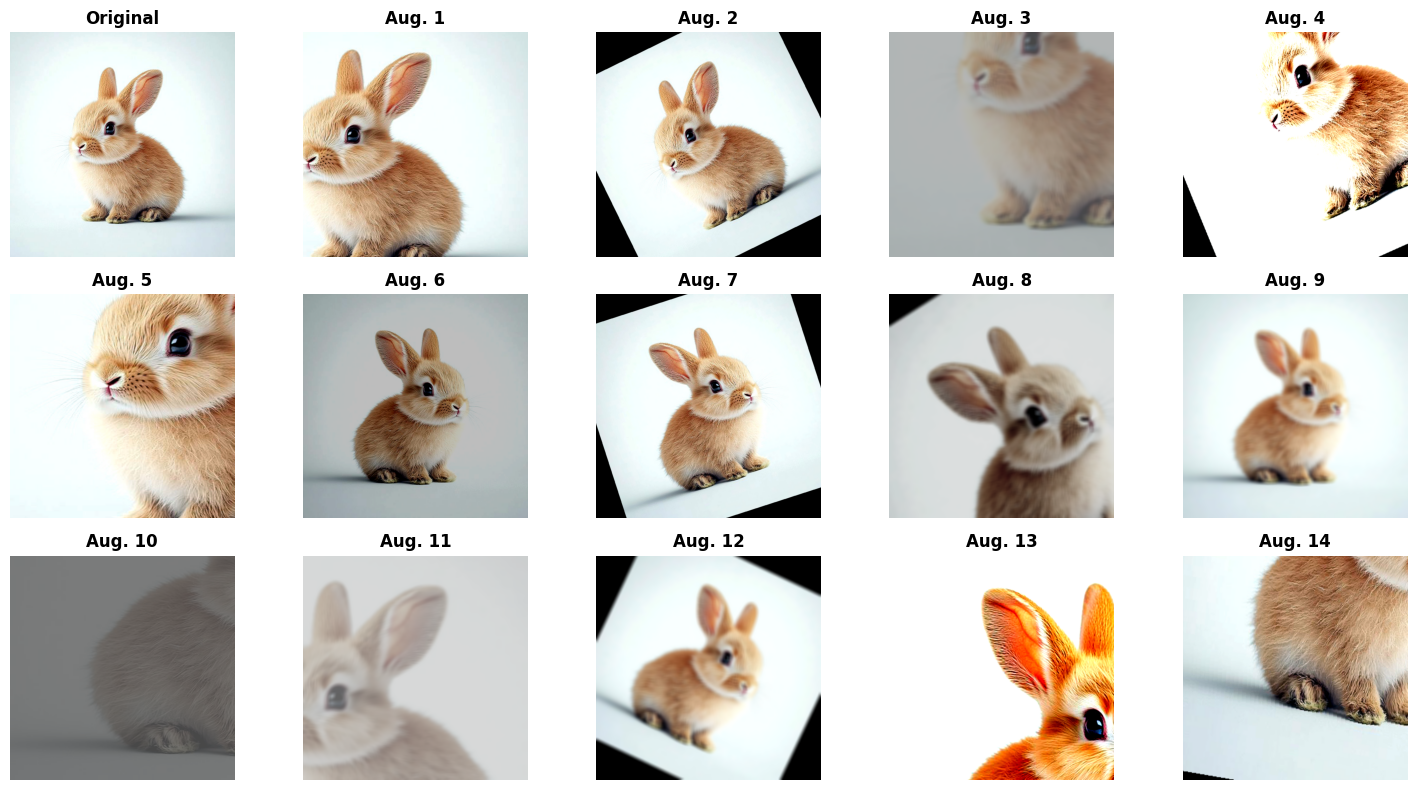

In [ ]:
n = 14  # Number of augmentations

# Set seed for reproducibility
torch.manual_seed(42)

# URL of the image
url = "https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C01/rabbit.jpg"

# Download and load the image
with urllib.request.urlopen(url) as response:
    original_image = Image.open(BytesIO(response.read())).convert("RGB")
original_array = np.array(original_image)

# Define augmentation probabilities
augmentation_probs = {
    'rotation': 0.25,    # 25% chance
    'flipping': 0.5,     # 50% chance
    'cropping': 0.75,    # 75% chance
    'color_jitter': 0.5, # 50% chance
    'blur': 0.5          # 50% chance
}

# Define transforms
transforms = T.Compose([
    T.RandomApply([T.RandomRotation(degrees=(-30, 30))], p=augmentation_probs['rotation']),
    T.RandomHorizontalFlip(p=augmentation_probs['flipping']),
    T.RandomApply([T.RandomResizedCrop(size=original_image.size[::-1], scale=(0.2, 0.5))], p=augmentation_probs['cropping']),
    T.RandomApply([T.ColorJitter(brightness=0.75, contrast=0.75, saturation=0.75)], p=augmentation_probs['color_jitter']),
    T.RandomApply([T.GaussianBlur(kernel_size=15, sigma=(10, 20))], p=augmentation_probs['blur'])
])

# Function to apply augmentation
def augment_image(image):
    return transforms(image)

# Apply augmentation n times
augmented_images = [augment_image(original_image) for _ in range(n)]

# Visualization in a grid
cols = 5
rows = (n + 1 + cols - 1) // cols  # Add 1 for original image
plt.figure(figsize=(15, 8))

# Original image
plt.subplot(rows, cols, 1)
plt.imshow(original_array)
plt.title("Original", fontweight="bold")
plt.axis("off")

# Augmented images
for i, aug_img in enumerate(augmented_images, 1):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(np.array(aug_img))
    plt.title(f"Aug. {i}", fontweight="bold")
    plt.axis("off")

plt.tight_layout()
plt.show()

### **AlexNet on Fashion-MNIST**

In the previous chapter, we trained a **shallow CNN** on the Fashion-MNIST dataset. The results weren’t acceptable though—the validation accuracy and F1-score were low. But remember that the issue wasn’t with CNNs being weak (they had performed very well on the simpler MNIST digit dataset) the problem was the network’s simplicity. Digits are easy to distinguish with fewer features (some simple lines and curves), while clothing items require deeper feature extraction. Thus, now that we know the power of deep CNNs, we can try **AlexNet**, a deep architecture with additional layers and filters designed to capture those details.

To save time, we’ll use the `torch` library rather than re-implementing every layer from scratch. Since we already understand how convolution, pooling, and fully connected layers work, we can focus here on applying them effectively.

Training AlexNet on the whole Fashion-MNIST train set would give a much more reasonable validation accuracy $91.9 \%$ than the $84.68 \%$ of our previous shallow CNN model (you may experiment it by setting `FRACTION = 1.0` in the code below and execute it). It can already prove the power of depth in CNNs. But what we will defend in here is not the power of deep CNNs anymore, it's something else.

---

### **Power of Data Augmentation**

Remember our strawberry example from the previous section? We mentioned one of the key weak points of Dense Neural Networks: their **poor shift, scale, and rotation invariance**. To make a Dense Network recognize strawberries in any position, size, or orientation, we would have needed an **explosion of training images**—strawberries in the top-right corner, bottom-left corner, scaled differently, rotated at every possible angle. We agreed that creating such a dataset would be **costly, inefficient, and practically impossible**.  

Yet, here we are, and suddenly **data augmentation** is introduced as a “magic wand” for CNNs. At first glance, it seems absurd: aren’t we doing the exact same thing we said was impractical for Dense Networks? How can it be a weak point for one type of network but a strength for another?  

Here’s the key difference: Dense Networks treat inputs as **flat numbers**, meaning they have **no concept of spatial structure**. Every variation—shifted, scaled, or rotated—must be **memorized independently**, because the network cannot intrinsically understand that an edge in one position is related to the same edge elsewhere. That’s why we would have needed countless strawberry images.  

CNNs, on the other hand, are built to understand **local patterns**. Convolutional layers learn **edges, textures, and shapes** in a way that is **position-independent**. When we apply flips, rotations, or crops, we’re not forcing the network to memorize new images; we’re giving it **more opportunities to see the same features in different contexts**, which naturally aligns with the way CNNs interpret images. In other words, **data augmentation leverages the network’s inherent structure**, instead of overwhelming it with meaningless repetitions.  

> Think of it like this: Dense Networks are like students who must memorize each strawberry individually, while CNNs are like students who understand the concept of “strawberry-ness” and can recognize it whether it’s on the left, right, or upside-down. Augmentation is simply giving the CNN more contexts to practice this understanding.  

So yes—it might seem like a “magic trick,” but it’s a **clever, principled, and powerful strategy**, not a contradiction. This is one of the reasons why AlexNet was so successful: **it combined deep architectures with smart data augmentation**, turning a potential limitation into a decisive strength.

To really see how data augmentation changes the game, let’s set up two experiments under **identical conditions**:

* Same architecture (AlexNet)
* Same dataset (only 5% of Fashion-MNIST, about 3,000 images)

This makes the comparison fair and clear. Notice that AlexNet is a **very powerful model** with millions of parameters, but we’re asking it to learn from a very small dataset. It’s a bit like trying to teach a genius who has the capacity to learn an entire library, but you only give them a childbook — they’ll memorize every word in every page, but they won’t actually “understand” the world. In machine learning terms, that’s classic **overfitting**.

* **Experiment 1 (No Augmentation):**
  We train AlexNet directly on the raw 5% subset. As expected, it overfits badly: training loss goes down, but validation loss is high. The model memorizes instead of generalizing, and its ability to handle unseen data is poor.

* **Experiment 2 (With Augmentation):**
  Now we use the **exact same subset of 3,000 images**, but this time, for every image we generate three new variations:

  * A horizontally flipped version
  * A noisy version
  * A randomly cropped and resized version

  That instantly turns our 3,000 images into \~12,000. Nothing about the network changes — only the training data is enriched. And the results are striking: the F1-score jumps from **0.79** to **0.86**, and validation loss drops.

By artificially expanding the dataset, we bring balance between the **capacity of the model** and the **amount of training data available**. Instead of a genius stuck with a handful of nursery rhymes, we’ve now given them a much larger, more varied library to study from — still limited, but diverse enough to learn real patterns rather than just memorizing.

In [ ]:
import os
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, Subset, ConcatDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# Model parameters for Fashion-MNIST
IMAGE_DIM = 28    # Image size (28x28 pixels)
NUM_CLASSES = 10  # Total classes
FRACTION = 0.05   # Set to 1.0 to experiment on the whole dataset
CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

In [ ]:
# Adapted AlexNet for Fashion-MNIST (grayscale, smaller images)
class AlexNetFashionMNIST(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super(AlexNetFashionMNIST, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),  # Input: 1 channel, output: 64 channels, size remains 28x28
            nn.ReLU(inplace=True),                                 # Activation
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Downsample to 14x14
            nn.Conv2d(64, 192, kernel_size=3, padding=1),          # Output: 192 channels, size 14x14
            nn.ReLU(inplace=True),                                 # Activation
            nn.MaxPool2d(kernel_size=2, stride=2),                 # Downsample to 7x7
            nn.Conv2d(192, 384, kernel_size=3, padding=1),         # Output: 384 channels, size 7x7
            nn.ReLU(inplace=True),                                 # Activation
            nn.Conv2d(384, 256, kernel_size=3, padding=1),         # Output: 256 channels, size 7x7
            nn.ReLU(inplace=True),                                 # Activation
            nn.Conv2d(256, 256, kernel_size=3, padding=1),         # Output: 256 channels, size 7x7
            nn.ReLU(inplace=True),                                 # Activation
            # No further pooling to keep size at 7x7
        )
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),                                     # Dropout to prevent overfitting
            nn.Linear(256 * 7 * 7, 4096),                          # Flatten and connect to 4096 units
            nn.ReLU(inplace=True),                                 # Activation
            nn.Dropout(p=0.5),                                     # Dropout to prevent overfitting
            nn.Linear(4096, 1024),                                 # Connect to 1024 units (reduced for speed)
            nn.ReLU(inplace=True),                                 # Activation
            nn.Linear(1024, num_classes),                          # Output layer for classification (skipped softmax)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)  # Flatten for classifier
        return self.classifier(x)

# Create the model
def create_model(num_classes):
    return AlexNetFashionMNIST(num_classes=num_classes).to(device)

# Create Adam optimizer
def create_optimizer(model):
    return optim.Adam(model.parameters(), lr=0.001)

# Create loss function
def create_criterion():
    return nn.CrossEntropyLoss()

# Function to get a limited subset of the full dataset
def get_subset(dataset, fraction=FRACTION):
    dataset_size = len(dataset)
    indices = np.random.choice(dataset_size, int(dataset_size * fraction), replace=False)
    return Subset(dataset, indices)

# Function to augment the dataset
def augment_dataset(dataset):
    """Add augmented versions of images to expand the dataset."""
    flip_transform = T.Compose([T.RandomHorizontalFlip(p=1.0), T.ToTensor()])
    noise_transform = T.Compose([T.ToTensor(), T.RandomErasing(p=1.0)])
    crop_transform = T.Compose([T.ToTensor(), T.RandomResizedCrop(size=IMAGE_DIM, scale=(0.8, 1.0), ratio=(1, 1))])

    # Create augmented subsets from the full trainset
    trainset_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=flip_transform)
    flipped_subset = get_subset(trainset_full, fraction=FRACTION)
    trainset_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=noise_transform)
    noisy_subset = get_subset(trainset_full, fraction=FRACTION)
    trainset_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=crop_transform)
    cropped_subset = get_subset(trainset_full, fraction=FRACTION)

    # Combine original subset with augmented subsets
    augmented_dataset = ConcatDataset([dataset, flipped_subset, noisy_subset, cropped_subset])
    return augmented_dataset

# Load Fashion-MNIST with a fraction of full trainset
def load_data(augment=False, batch_size=64):
    transform_train = T.Compose([
        T.ToTensor(),
        T.Normalize((0.1307,), (0.3081,)),  # Fashion-MNIST mean/std
    ])

    transform_test = T.Compose([
        T.ToTensor(),
        T.Normalize((0.1307,), (0.3081,)),
    ])

    # Load full datasets
    trainset_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_train)
    testset_full = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform_test)

    # Get a fraction of the full trainset
    trainset = get_subset(trainset_full, fraction=FRACTION)
    testset = get_subset(testset_full, fraction=FRACTION)  # Optional: a fraction of test set for consistency

    # Augment if requested (only applied to the training set)
    if augment:
        trainset = augment_dataset(trainset)

    trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, worker_init_fn=lambda x: np.random.seed(42))
    testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, worker_init_fn=lambda x: np.random.seed(42))

    return trainloader, testloader, NUM_CLASSES

# Train the model
def train_model(model, trainloader, criterion, optimizer, device, epochs=10):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        progress_bar = tqdm(enumerate(trainloader), total=len(trainloader), desc=f"Epoch {epoch+1}/{epochs}")
        for i, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            progress_bar.set_postfix(loss=running_loss / (i + 1))

# Evaluate the model
def evaluate_model(model, testloader, criterion, device):
    model.eval()
    correct = 0
    total = 0
    test_loss = 0.0
    all_labels = []
    all_preds = []

    progress_bar = tqdm(enumerate(testloader), total=len(testloader), desc="Evaluation: ")
    with torch.no_grad():
        for i, (inputs, labels) in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            progress_bar.set_postfix(loss=test_loss / (i + 1), accuracy=100 * correct / total)

    accuracy = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    ConfusionMatrixDisplay(cm, display_labels = CLASS_NAMES).plot(cmap='Blues')
    plt.title(f'F1-Score: {f1:.6f}')
    plt.xticks(rotation = 45)
    plt.show()

# Run the experiment
def run_experiment(augment=False, epochs=4):
    torch.manual_seed(42)  # Seed for PyTorch
    np.random.seed(42)    # Seed for NumPy
    torch.cuda.manual_seed_all(42)  # Seed for all GPUs if using CUDA
    torch.backends.cudnn.deterministic = True

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    trainloader, testloader, num_classes = load_data(augment=augment)

    model = create_model(num_classes=num_classes)
    criterion = create_criterion()
    optimizer = create_optimizer(model)

    print(f"Training with {'augmentation' if augment else 'no augmentation'} on {FRACTION*100}% of the whole Fashion-MNIST dataset")
    train_model(model, trainloader, criterion, optimizer, device, epochs=epochs)

    print("\n\nTraining Done\nEvaluating model...")
    evaluate_model(model, testloader, criterion, device)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.61MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.2MB/s]


Training with no augmentation on 5.0% of the whole Fashion-MNIST dataset


Epoch 4/4: 100%|██████████| 47/47 [00:01<00:00, 27.78it/s, loss=0.595]



Training Done
Evaluating model...



Evaluation: 100%|██████████| 8/8 [00:00<00:00, 30.22it/s, accuracy=79.4, loss=0.622]


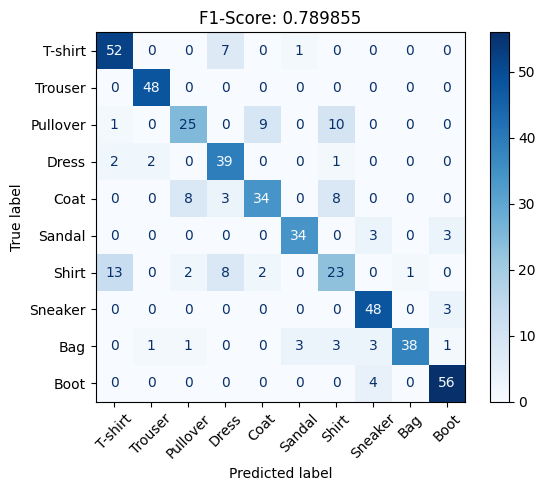

In [ ]:
# Training without augmentation
run_experiment(augment=False, epochs=4)

Training with augmentation on 5.0% of the whole Fashion-MNIST dataset


Epoch 4/4: 100%|██████████| 188/188 [00:06<00:00, 28.50it/s, loss=0.447]




Training Done
Evaluating model...


Evaluation: 100%|██████████| 8/8 [00:00<00:00, 47.19it/s, accuracy=86, loss=0.381]


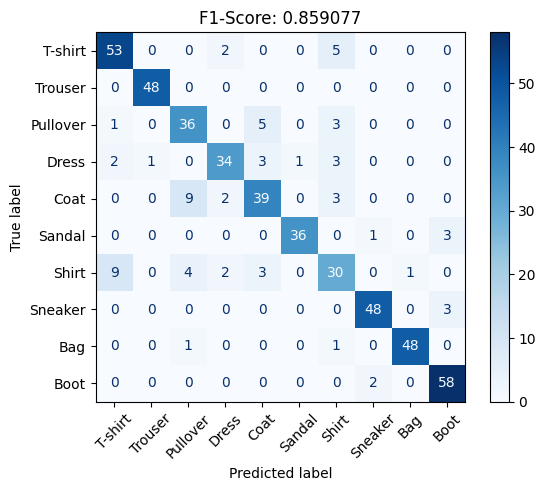

In [ ]:
# Training with augmentation
run_experiment(augment=True, epochs=4)

## **ResNet (Residual Networks)**

It looked like we had unlocked the ultimate cheat code for neural networks: **just make them deeper**. After AlexNet’s shockwave in 2012, everyone thought, "Let’s stack layers until we hit the hardware limit!" ZFNet emerged in 2013, tweaking the early layers yet still hovering around 8 layers; VGGNet pushed the envelope with 16–19 layers in 2014; and Google’s revolutionary GoogLeNet (Inception v1) rolled out with a whopping 22 layers—all chasing ever-decreasing error rates.
Yet all those extra layers didn’t bring the **steep drop in loss** that AlexNet had sparked. Instead, something unexpected happened: a **plateau** appeared, meaning that the whole progress **stopped dead in its tracks** no matter how many layers the engineers stacked on top of each other. Even the **training error refused to decrease** after a certain depth. That’s strange, isn’t it? At the very least, we would expect the model to overfit after many epochs—so the training error should keep going down, but it wouldn’t.  

<div align="center">  
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C01/grad_vanishing.png" width="600">  
  <h6>Figure 4: Deep neural networks stuck in a plateau</h6>  
</div>  

**Image Credit:** [Original Paper](https://arxiv.org/abs/1512.03385)  

And suddenly, this raised a contradiction: *Does adding more layers really help extract features more effectively? Is it even useful?* After all, researchers had already built networks with **100 layers**, but the performance was **disappointing**.  

What do you think was the reason? Well, it’s pretty much obvious—the problem was something we are already familiar with: **vanishing gradients** (covered in `Section04 - Chapter00`). By stacking more layers, we were also stacking more **activation functions**, and these activations often output zeros or very small numbers. The deeper the network gets (especially beyond **50 layers**), the more likely these tiny values shrink the gradients until learning **completely stalls**.  

The tide turned with the groundbreaking 2015 paper from Microsoft [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385), introducing a network with an astonishing 152 layers. This innovation, known as **ResNet (Residual Network)**, introduced **residual blocks** to conquer the gradient vanishing problem. These blocks allow the network to learn **residual functions**—the difference between the desired output and the input—rather than the entire transformation. Mathematically, a residual block can be expressed as:

$$
H(x) = F(x) + x
$$

Here, $x$ is the input to the block, $F(x)$ is the residual function (computed via layers with weights), and $H(x)$ is the output. The direct connection (a.k.a. skip connection) adds $x$ to $F(x)$, enabling gradients to flow more easily during backpropagation.
Now that our model learns $H(x) = F(x) + x$ instead of the direct $F(x)$, the gradients behave differently. The gradient with respect to the input $x$ becomes:

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial H} \cdot \frac{\partial H}{\partial x} = \frac{\partial L}{\partial H} \cdot \left( \frac{\partial F}{\partial x} + 1 \right)
$$

Here, the gradient from the upper layer ($\frac{\partial L}{\partial H}$) is multiplied by 1 (from the skip connection) plus the gradient of $F(x)$. This means that even if $F(x)$ outputs 0 — often due to `ReLU` clipping negatives or `Sigmoid/Tanh` catching huge positive or negative values — the gradient still flows through the skip connection (the $+1$ term), preventing the model from stalling. This bypass ensures weight updates continue, effectively overcoming gradient vanishing and enabling deeper networks to train successfully.

<div align="center">
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C01/res_block.png" width="400">
  <h6>Figure 5: A residual block in which $x$ flows freely through a <strong>skip connection</strong></h6>
</div>

**Image Credit:** [Original Paper](https://arxiv.org/abs/1512.03385)

This elegant solution not only revived deep learning but also paved the way for networks to grow deeper and more powerful, achieving remarkable accuracy on ImageNet and beyond.



###**ResNet on CIFAR-10**

To uncover the true power of residual blocks compared to plain blocks (the same ones used in VGGNet), we designed two deep models, each with around ~56 layers.  

- **Plain Network:** built entirely from plain convolutional blocks, without skip connections. Such deep networks are notoriously vulnerable to problems like **vanishing/exploding gradients**, slow convergence, and training plateaus.  
- **ResNet:** identical in depth, but with **residual blocks** that include skip connections. These shortcuts act like “express lanes” for gradients, allowing the network to learn much deeper representations without getting stuck.  

From the architecture summaries, we can see that the ResNet has slightly more parameters than the plain network — an overhead introduced by its skip connections. But both networks have an extremely large number of parameters, which means they can easily **overfit** if tested on simple datasets we have been using so far.  

That is why, instead of sticking with MNIST or Fashion-MNIST, we now move on to **CIFAR-10**:  
- A dataset of **60,000 colored images**, each of size **32×32 pixels**, spread across **10 distinct classes**.  
- Unlike MNIST, these images are **RGB** (3 channels) rather than grayscale.  
- Despite being a relatively simple dataset, CIFAR-10 is far more challenging than handwritten digits, making it a good test for deeper models.  

<div align="center">  
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C01/cifar_10.jpg" width="600">  
  <h6>Figure 6: Classes in CIFAR-10 dataset</h6>  
</div>

Once training was completed, the results spoke volumes.  

- **Training Dynamics:**  
  The **Plain CNN** started off strong with a steep learning curve, but quickly lost its pace. After several epochs its progress slowed dramatically, an obvious example of **vanishing gradients**. Had training continued, the model likely would have plateaued entirely.  
  In contrast, **ResNet** maintained its momentum almost throughout. Thanks to the skip connections in its residual blocks, gradients kept flowing and parameters kept updating. This prevented stagnation and allowed the model to push forward epoch after epoch.  

- **Accuracy Trends:**  
  **ResNet’s accuracy** started high and ended high, with stable, consistent improvements.  
  **Plain CNN’s accuracy** fluctuated heavily — rising, falling, and never converging smoothly.  

- **Confusion Matrices:**  
  The **Plain CNN’s confusion matrix** was chaotic:  
  - Planes were often mistaken for cars or ships.  
  - Deer were confused with horses.  
  - Most oddly, the model frequently mislabeled images as **“deer” or “frog”**, revealing a strong bias that is hard to explain (possibly due to imbalanced feature learning or overfitting on certain visual patterns).  

  The **ResNet confusion matrix**, however, was far more logical:  
  - The biggest challenge was **cats vs. dogs** (understandable, given how similar they appear at 32×32 resolution).  
  - Some overlap occurred between **cars and trucks**, again a very reasonable confusion.  
  Beyond these, ResNet showed remarkable clarity in distinguishing the remaining classes.  

- **Quantitative Comparison:**  
  - **Plain CNN F1 Score:** 0.56  
  - **ResNet F1 Score:** 0.88

This leap in performance demonstrates the **true magic of residual blocks**. By solving the vanishing gradient problem, ResNet opened the gates to training very deep networks that were once thought impossible.  

And historically, this was groundbreaking:  
- In 2015, **ResNet shocked the AI world by outperforming the average human on the ImageNet classification task.**  
- While humans typically misclassify about **5%** of images, ResNet achieved an error rate of just **3.6%**.  
- This was the **first time a neural network surpassed human-level accuracy** in such a large-scale vision challenge.  

From that moment on, ResNet didn’t just solve a training problem — it redefined what deep learning could achieve.

In [ ]:
from tqdm import trange
from torchsummary import summary

# Set seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.enabled = True

# Initialize seed at the start
set_seed(42)

EPOCHS = 40
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data Preprocessing: Normalize and augment CIFAR-10 (Section 00)
norm_mean = (0.4914, 0.4822, 0.4465)
norm_std = (0.2023, 0.1994, 0.2010)
batch_size = 128

transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(norm_mean, norm_std),
])

transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize(norm_mean, norm_std),
])

# Custom worker initialization for DataLoader
def worker_init_fn(worker_id):
    np.random.seed(42 + worker_id)  # Unique seed per worker

trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2, worker_init_fn=worker_init_fn)

testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, worker_init_fn=worker_init_fn)

CLASS_NAMES_C10 = testset.classes

# Plain VGG-Style Block (no residual)
class PlainBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(PlainBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        return out

# Residual Block (with skip connection)
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = None
        if stride != 1 or in_channels != out_channels:
            self.downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity  # Skip connection
        out = self.relu(out)
        return out

# Base CNN Class (configurable with block type)
class DeepCNN(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(DeepCNN, self).__init__()
        self.in_channels = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)
        # Create deep layers (>50 total: initial + 3 groups × num_blocks × 2 convs + FC)
        self.layer1 = self._make_layer(block, 16, num_blocks, stride=1)  # ~2*num_blocks layers
        self.layer2 = self._make_layer(block, 32, num_blocks, stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)  # Simplified for demo

    def _make_layer(self, block, out_channels, num_blocks, stride):
        layers = []
        layers.append(block(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            layers.append(block(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# Training function
def train_model(model, epochs=EPOCHS):
    set_seed(42)  # Re-seed before training
    optimizer = optim.Adam(model.parameters(), lr=1e-2)
    criterion = nn.CrossEntropyLoss()
    train_losses = []
    test_accs = []
    for epoch in (pbar := trange(epochs, desc='Training')):
        model.train()
        running_loss = 0.0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(trainloader)
        train_losses.append(avg_loss)

        # Test accuracy
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        test_acc = 100 * correct / total
        test_accs.append(test_acc)

        # Update progress bar
        pbar.set_description(f'Train Loss: {avg_loss:.4f} | Test Accuracy: {test_acc:.2f}%')

    return train_losses, test_accs

# Create models: Set num_blocks=9 for >50 layers (1 initial conv + 3*9*2 = 54 convs + FC ≈ 56 layers)
set_seed(42)  # Re-seed before model creation
plain_model = DeepCNN(PlainBlock, num_blocks=9).to(device)
resnet_model = DeepCNN(ResidualBlock, num_blocks=9).to(device)

# Show the architectures
print('Plain CNN Summary: ')
summary(plain_model, (3, 32, 32))
print('\nResNet Summary: ')
summary(resnet_model, (3, 32, 32))

100%|██████████| 170M/170M [00:02<00:00, 62.7MB/s]


Plain CNN Summary: 
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             432
       BatchNorm2d-2           [-1, 16, 32, 32]              32
              ReLU-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 16, 32, 32]           2,304
       BatchNorm2d-5           [-1, 16, 32, 32]              32
              ReLU-6           [-1, 16, 32, 32]               0
            Conv2d-7           [-1, 16, 32, 32]           2,304
       BatchNorm2d-8           [-1, 16, 32, 32]              32
              ReLU-9           [-1, 16, 32, 32]               0
       PlainBlock-10           [-1, 16, 32, 32]               0
           Conv2d-11           [-1, 16, 32, 32]           2,304
      BatchNorm2d-12           [-1, 16, 32, 32]              32
             ReLU-13           [-1, 16, 32, 32]               0
           Conv2d-1

In [ ]:
# Train both models
print("Training Plain CNN...")
plain_losses, plain_accs = train_model(plain_model)
print("\nTraining ResNet...")
resnet_losses, resnet_accs = train_model(resnet_model)

Training Plain CNN...


Train Loss: 0.7147 | Test Accuracy: 58.80%: 100%|██████████| 40/40 [28:54<00:00, 43.37s/it]



Training ResNet...


Train Loss: 0.1437 | Test Accuracy: 88.15%: 100%|██████████| 40/40 [31:07<00:00, 46.68s/it]


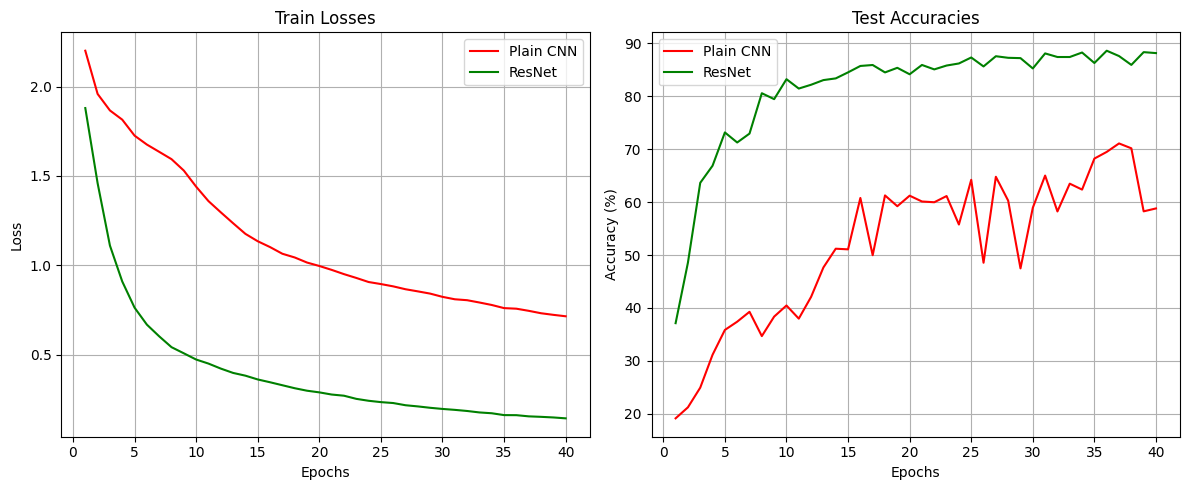

In [ ]:
import seaborn as sns

# Shorten first two words ('airplane' -> 'plane' and 'automobile' -> 'car')
CLASS_NAMES_C10[:2] = ['plane', 'car']

# Function to plot the curves
def plot_curves(loss1, loss2, acc1, acc2, model1='Plain CNN', model2='ResNet', epochs=EPOCHS):
    epochs_range = range(1, epochs+1)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].plot(epochs_range, loss1, 'r-', label=model1)
    axs[0].plot(epochs_range, loss2, 'g-', label=model2)
    axs[0].set_title('Train Losses')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].legend()
    axs[0].grid()
    axs[1].plot(epochs_range, acc1, 'r-', label=model1)
    axs[1].plot(epochs_range, acc2, 'g-', label=model2)
    axs[1].set_title('Test Accuracies')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Accuracy (%)')
    axs[1].legend()
    axs[1].grid()
    plt.tight_layout()
    plt.show()

# Function to plot confusion matrix
def plot_confusion_matrix(model, model_name, testloader, class_names=CLASS_NAMES_C10, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    all_preds = []
    all_labels = []

    # Collect predictions and true labels from test set
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix and F1-score
    cm = confusion_matrix(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')  # Weighted F1-score for multi-class

    # Plot confusion matrix
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} | F1-Score: {f1:.4f}', fontsize=12, fontweight='bold')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Visualize some random test images with predictions
def visualize_images(model1, model2, m1_name='Plain', m2_name='ResNet', images_set=testset, class_names=CLASS_NAMES_C10, data_mean=norm_mean, data_std=norm_std, s=42):
    def get_predictions(model, images):
        model.eval()
        with torch.no_grad():
            outputs = model(images.to(device))
            _, preds = torch.max(outputs, 1)
        return preds.cpu().numpy()

    # Select some random test images
    np.random.seed(s)
    indices = np.random.choice(len(images_set), 28, replace=False)
    images = torch.stack([images_set[i][0] for i in indices])
    labels = [images_set[i][1] for i in indices]

    model1_preds = get_predictions(model1, images)
    model2_preds = get_predictions(model2, images)

    # Denormalize for display
    denorm = T.Normalize(mean=[-m/s for m, s in zip(data_mean, data_std)], std=[1/s for s in data_std])
    images_denorm = torch.stack([denorm(img) for img in images]).clamp(0, 1)

    fig, axs = plt.subplots(4, 7, figsize=(15, 12))
    for i, ax in enumerate(axs.flatten()):
        ax.imshow(images_denorm[i].permute(1, 2, 0).numpy())
        true_label = class_names[labels[i]]
        m1_pred = class_names[model1_preds[i]]
        m2_pred = class_names[model2_preds[i]]

        # Set colors: green if prediction matches true label, red if not
        m1_color = 'green' if m1_pred == true_label else 'red'
        m2_color = 'green' if m2_pred == true_label else 'red'

        # Create title with colored lines using separate text calls
        ax.text(0.5, 1.30, f'True: {true_label}', fontsize=13, ha='center', va='top', transform=ax.transAxes, fontweight='bold')
        ax.text(0.5, 1.20, f'{m1_name}: {m1_pred}', fontsize=13, ha='center', va='top', color=m1_color, transform=ax.transAxes, fontweight='bold')
        ax.text(0.5, 1.10, f'{m2_name}: {m2_pred}', fontsize=13, ha='center', va='top', color=m2_color, transform=ax.transAxes, fontweight='bold')

        ax.axis('off')

    plt.tight_layout(pad=2.0, h_pad=2.0, w_pad=1.0)  # Adjusted padding for clarity
    plt.show()

plot_curves(plain_losses, resnet_losses, plain_accs, resnet_accs)

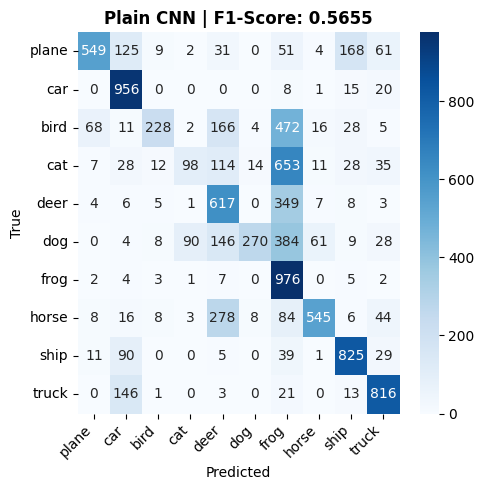

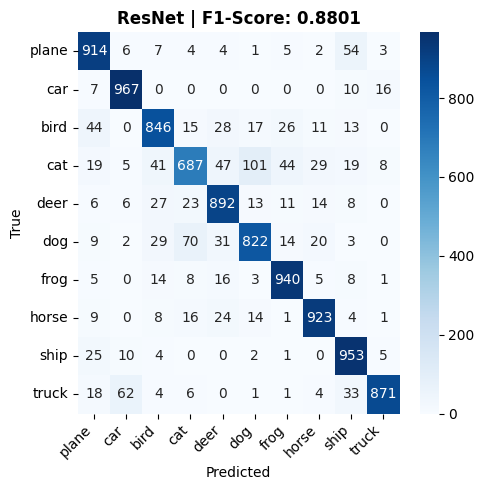

In [ ]:
plot_confusion_matrix(plain_model, "Plain CNN", testloader, CLASS_NAMES_C10, device)
plot_confusion_matrix(resnet_model, "ResNet", testloader, CLASS_NAMES_C10, device)

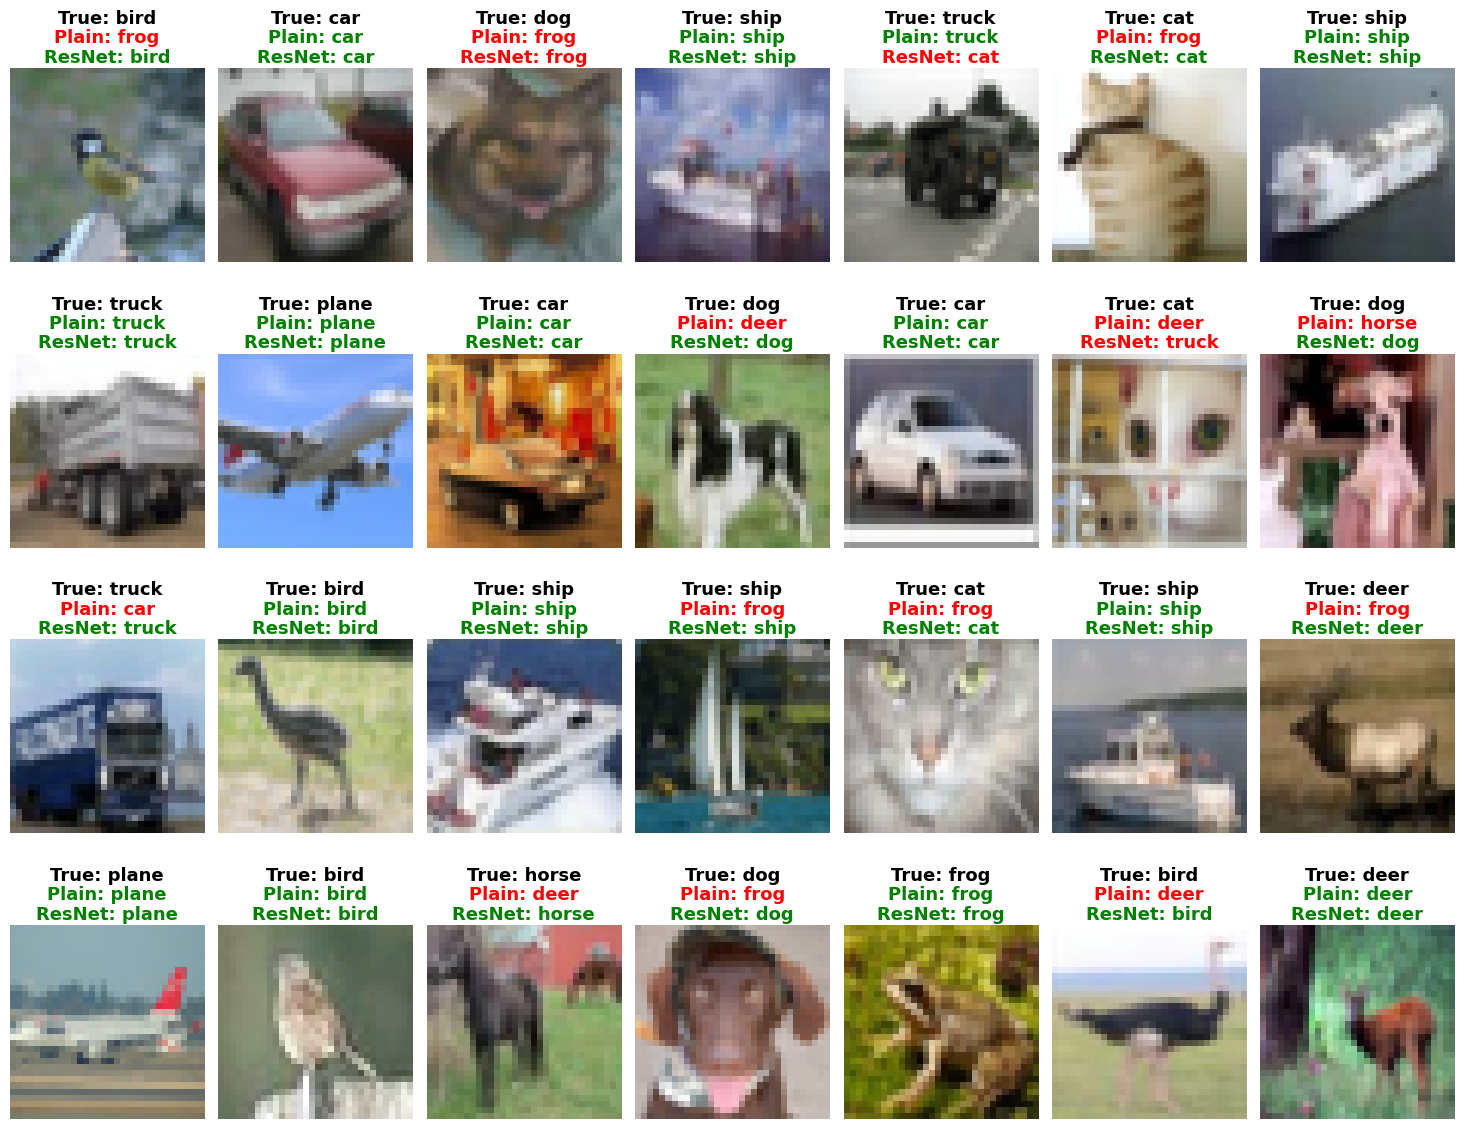

In [ ]:
visualize_images(plain_model, resnet_model)

##**Transfer Learning**

Imagine two students join a Kung-fu club. Both have the same height, weight, and fitness level. Neither has practiced Kung-fu before — but one of them has a background in boxing.  

At first, you might think boxing and Kung-fu are very different. True, the techniques are not the same, but the boxer’s **prior experience with discipline, body coordination, reflexes, and stamina** gives him a huge advantage. His first training days are smoother, less painful, and more effective. Within weeks, his progress would far surpass the beginner who has never trained in any sport.  

This doesn’t just apply to boxing — even if his background were in football or swimming, the prior athletic experience would still accelerate his Kung-fu learning compared to a complete novice.  

Now, here’s the twist: **machines learn the same way.**  

Instead of training a model from scratch on a brand-new dataset, we can give it a **head start** by first training it on a large, general dataset (like ImageNet). Then, when we introduce the new dataset, we **freeze most of the early layers** — those layers already contain useful general features like edges, shapes, and textures. We only update the later layers (the fully connected and sometimes the last convolutional layers), which specialize the network for the new task.  

This strategy is called **Transfer Learning**.  
It’s like giving the model a sports background before it joins the Kung-fu club — less pain, faster progress, and often far better results than starting from scratch.  

---

###**Why Would Transfer Learning Work?**

When training a CNN from scratch, the **early layers** always end up learning very general visual features — simple patterns like lines, curves, circles, textures, and color contrasts. The **middle layers** combine those into slightly more complex shapes and structures, it's only the **final layers** who become highly specialized for the specific dataset (for example, detecting cat ears vs. dog noses).  

This is the core reason transfer learning works:  
- The early layers are **universal feature detectors**. They don’t care if the dataset is cats, airplanes, or humans — edges are edges, circles are circles.  
- The later layers are **dataset-specific**. That’s where we adapt the network to the new task.  

By freezing the early layers of a pre-trained model, we’re essentially saying:  
> *“Don’t waste time re-learning edges, curves, and textures. Those are already figured out. Just focus on how to combine them for this new problem.”*  

This gives the model a **head start**: it starts with a smaller loss and usually achieves much higher accuracy much faster compared to training from scratch.  

Returning to our Kung-fu analogy:  
- A trainee who already trained in boxing doesn’t need to waste time and energy to learn push-ups, basic conditioning, or punching power.  
- Instead, he can directly focus on Kung-fu-specific skills, combining his general athletic background with new movements.  
- A complete beginner, however, must first struggle through all the basics before even touching advanced techniques.  

But — there’s a catch. **Transfer only works well when the pre-training and the new task share similarities.**  
- A model pre-trained on millions of animal images (ImageNet) transfers beautifully to a task like distinguishing cats vs. dogs.  
- But if we take that same model and try to train it on X-ray scans for bone fractures, the “knowledge transfer” won’t help much — the features it learned (fur textures, eye shapes, colors) don’t apply to grayscale medical images.  

This is like our sports analogy again:  
- A boxer adapts well to Kung-fu.  
- A kickboxer adapts even better, since the skillsets are closer.  
- A swimmer still has some advantage (fitness, stamina), but much less relevant for fighting.  

In the same way, a pre-trained model’s effectiveness depends on **how close the source and target datasets are.**

### **GPTs as Pretrained Models**

The **P** in GPT stands for **Pre-trained**. Before ChatGPT can be specialized for any particular task, it first goes through a large-scale pre-training phase. In this stage, it is exposed to massive and diverse datasets drawn from books, articles, websites, and countless examples of human language. This broad training allows it to acquire a general understanding of grammar, vocabulary, reasoning, and knowledge across many domains—essentially giving it a strong foundation in how humans communicate.

Once this foundation is built, ChatGPT can then be adapted or fine-tuned for specific use cases. For example, a company might train it further on their own documents so it can act as a customer support agent, or developers may adjust it to align with certain tones or personalities. Even in casual conversations, ChatGPT refines how it interacts by responding to user preferences and conversational style. This process mirrors the concept of **transfer learning**: the model doesn’t need to learn language from scratch each time—it reuses its general pre-training and only adjusts the later layers to specialize for the new task.

### **Implementation on CIFAR-100**

As proof of the power of pretrained models, let’s now work with a much more complicated dataset: **CIFAR-100**. Like CIFAR-10, it contains 60,000 images at 32×32 resolution in RGB format, but with a critical difference: instead of 10 broad categories, it is split into **20 superclasses**, each containing **5 subclasses**, making a total of **100 distinct classes** (600 images per class). These classes span a wide range of objects—from aquatic mammals such as beaver, dolphin, and whale, to fruits, vegetables, buildings, and even people. This means the model is no longer distinguishing only between simple categories (like car vs. frog, as in CIFAR-10), but must now learn to separate far subtler differences, such as distinguishing between baby, boy, girl, man, and woman.

<div align="center">  
  <img src="https://raw.githubusercontent.com/MamoMGD1/ML_101/main/images/S05_C01/cifar_100.png" width="700">  
  <h6>Figure 7: Some of the images in CIFAR-100 dataset</h6>  
</div>

Naturally, this raises the difficulty dramatically. Even a deep **56-layer ResNet** struggles to achieve high accuracy. Unlike in CIFAR-10, where random initialization still gave the model a decent starting point (often around 40–50% accuracy), here the model begins at around **4–5% accuracy**. This happens because the model must first spend many epochs just discovering very basic patterns before it can even begin to generalize across so many fine-grained categories. The very first epochs of training a ResNet are often “wasted” on learning extremely basic and general features like discovering the fact that simple properties like colors, edges, and corners can act as useful separators between images. These are not unique to CIFAR-100—or to any dataset at all—but rather universal building blocks present in nearly every picture. Only after many epochs spent on these low-level patterns can the network gradually move on to more complex and dataset-specific features.

As expected, progress is slow, and climbing beyond 50% accuracy takes significant time and training power. Then if you remember, we had already trained a ResNet earlier on CIFAR-10. That network had the *exact same number of layers* as a completely new ResNet—so in theory, their learning power is identical. But here’s the key difference: the pre-trained ResNet already **knows something fundamental about images**. Its first layers have developed a strong understanding of lines, shapes, edges, and colors—the universal building blocks of vision.  

Now imagine we freeze those early layers and only allow the deeper layers and the final fully connected layer to update. Instead of wasting precious epochs rediscovering these simple but crucial features, the model immediately begins focusing on *higher-level patterns unique to CIFAR-100*. The result? It learns faster, it suffers less from high initial loss, and it reaches **significantly better accuracy** than a ResNet starting from scratch.

---

### **Notes on This Project**

From the summaries, notice that the total number of parameters is exactly the same in both models. The difference lies in the **42,512 non-trainable parameters** of the pretrained ResNet—those are the frozen weights of Layer 1. This freezing not only reduces the training load but also cuts each epoch’s runtime to nearly *half* of what a completely new ResNet requires.  

But the most striking part is performance. The pretrained ResNet begins training with a loss nearly **half** that of the new ResNet, and with an accuracy almost **10 times higher**. In fact, the pretrained model starts at an accuracy level that takes a fresh ResNet about **8 full epochs** to reach—essentially putting it eight steps ahead right from the beginning.  

**But...**

It’s important to emphasize that the pretraining method we used here is **not the standard approach** to Transfer Learning. Normally, transfer learning starts with a model trained on a **very large and diverse dataset**, and then that pretrained model is fine-tuned on a **much smaller, domain-specific dataset**.  

Consider a real-world scenario: imagine we only have **20 CT-Scan images** of a very rare cancer type. Training a deep network from scratch on such a tiny dataset would almost certainly lead to **overfitting**. And unlike natural images, CT-Scans don’t easily allow augmentation tricks:  
- Flipping horizontally or vertically would change the anatomical meaning.  
- Color jitter or brightness adjustments don’t apply since scans are grayscale.  
- Random crops risk removing the very small cancerous regions of interest.  

In this case, a far better strategy is to **pretrain on a very large dataset of diverse cancer images**. The model’s early layers would then already know how to detect general cancer-related features, and by fine-tuning only the higher layers, it could specialize for that rare type with much better accuracy.  

Our approach, however, was different. Due to storage and computational limits, we reused a **pretrained ResNet on CIFAR-10** and fine-tuned it on **CIFAR-100**. This is essentially the reverse of the standard method (specific → general). Naturally, it’s less effective, but it still demonstrated the same principle: the pretrained model consistently outperformed training from scratch.  

Finally, another factor to note is that even a **56-layer ResNet** might not be deep enough to fully master the complexity of 100 classes. But that wasn’t the core goal here. The real point of this project was to show that **pretraining works—and even in a non-standard setup, the pretrained model pulled ahead and proved the concept beautifully.**


In [ ]:
from copy import deepcopy

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Make cuDNN deterministic
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"  # Needed for CUDA >10.2
set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
norm_mean_100 = (0.5071, 0.4867, 0.4408)  # CIFAR-100 means
norm_std_100 = (0.2675, 0.2565, 0.2761)   # CIFAR-100 stds
batch_size = 128

transform_train = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(norm_mean_100, norm_std_100),
])

transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize(norm_mean_100, norm_std_100),
])

# Load CIFAR-100
trainset_100 = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
trainloader_100 = DataLoader(trainset_100, batch_size=batch_size, shuffle=True, num_workers=2, worker_init_fn=lambda x: np.random.seed(42 + x))

testset_100 = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
testloader_100 = DataLoader(testset_100, batch_size=batch_size, shuffle=False, num_workers=2, worker_init_fn=lambda x: np.random.seed(42 + x))
CLASS_NAMES_C100 = testset_100.classes

# Assume resnet_model is a pre-trained model from CIFAR-10 (10 classes)
# Rename and prepare for transfer learning
pre_trained_resnet = deepcopy(resnet_model)  # Deep copy the whole model

# Freeze all layers except the last few (e.g. layer2, layer3 and fc)
for param in pre_trained_resnet.parameters():
    param.requires_grad = False

# Unfreeze layer2, layer3 and fc for fine-tuning
for param in pre_trained_resnet.layer2.parameters():
    param.requires_grad = True
for param in pre_trained_resnet.layer3.parameters():
    param.requires_grad = True
for param in pre_trained_resnet.fc.parameters():
    param.requires_grad = True

# Replace classifier for CIFAR-100 (100 classes)
pre_trained_resnet.fc = nn.Linear(pre_trained_resnet.fc.in_features, 100).to(device)

# Create new_resnet_model from scratch (same architecture, random weights)
set_seed(42)  # Ensure consistent initialization
new_resnet_model = DeepCNN(ResidualBlock, num_blocks=9).to(device)  # From previous definition
new_resnet_model.fc = nn.Linear(new_resnet_model.fc.in_features, 100).to(device)  # Match classes

# Training function (adapted for new dataset)
def train_model(model, trainloader, testloader, epochs=50, lr=0.01):
    set_seed(42)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)  # Only trainable params for pre-trained
    criterion = nn.CrossEntropyLoss()
    train_losses = []
    test_accs = []
    for epoch in (pbar := trange(epochs, desc='Training')):
        model.train()
        running_loss = 0.0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(trainloader)
        train_losses.append(avg_loss)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in testloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        test_acc = 100 * correct / total
        test_accs.append(test_acc)

        pbar.set_description(f'Train Loss: {avg_loss:.4f} | Test Accuracy: {test_acc:.2f}%')

    return train_losses, test_accs

# Show the architectures
print('New ResNet Summary: ')
summary(new_resnet_model, (3, 32, 32))
print('\nPre-Trained ResNet Summary: ')
summary(pre_trained_resnet, (3, 32, 32))

100%|██████████| 169M/169M [00:05<00:00, 28.5MB/s]


New ResNet Summary: 
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 16, 32, 32]             432
       BatchNorm2d-2           [-1, 16, 32, 32]              32
              ReLU-3           [-1, 16, 32, 32]               0
            Conv2d-4           [-1, 16, 32, 32]           2,304
       BatchNorm2d-5           [-1, 16, 32, 32]              32
              ReLU-6           [-1, 16, 32, 32]               0
            Conv2d-7           [-1, 16, 32, 32]           2,304
       BatchNorm2d-8           [-1, 16, 32, 32]              32
              ReLU-9           [-1, 16, 32, 32]               0
    ResidualBlock-10           [-1, 16, 32, 32]               0
           Conv2d-11           [-1, 16, 32, 32]           2,304
      BatchNorm2d-12           [-1, 16, 32, 32]              32
             ReLU-13           [-1, 16, 32, 32]               0
           Conv2d-

In [ ]:
# Train both on CIFAR-100
print("Training New ResNet (From Scratch)...")
new_losses, new_accs = train_model(new_resnet_model, trainloader_100, testloader_100, 20)

print("\nTraining Pre-Trained ResNet (Previously Trained on CIFAR10)...")
pre_losses, pre_accs = train_model(pre_trained_resnet, trainloader_100, testloader_100, 20)

Training New ResNet (From Scratch)...


Train Loss: 1.1674 | Test Accuracy: 57.35%: 100%|██████████| 20/20 [16:23<00:00, 49.17s/it]



Training Pre-Trained ResNet (Previously Trained on CIFAR10)...


Train Loss: 0.8361 | Test Accuracy: 60.64%: 100%|██████████| 20/20 [11:55<00:00, 35.77s/it]


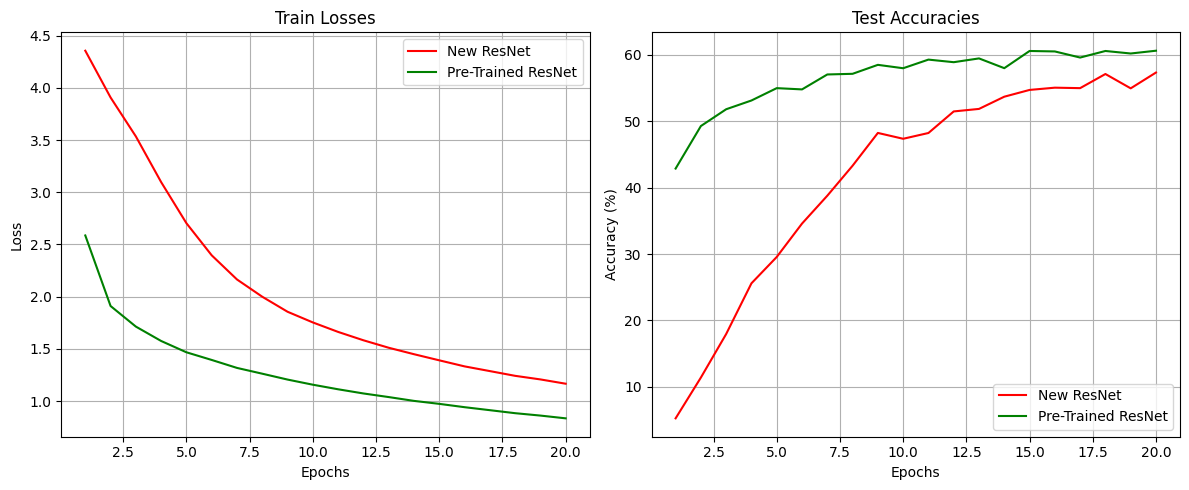

In [ ]:
plot_curves(new_losses, pre_losses, new_accs, pre_accs, 'New ResNet', 'Pre-Trained ResNet', epochs=20)

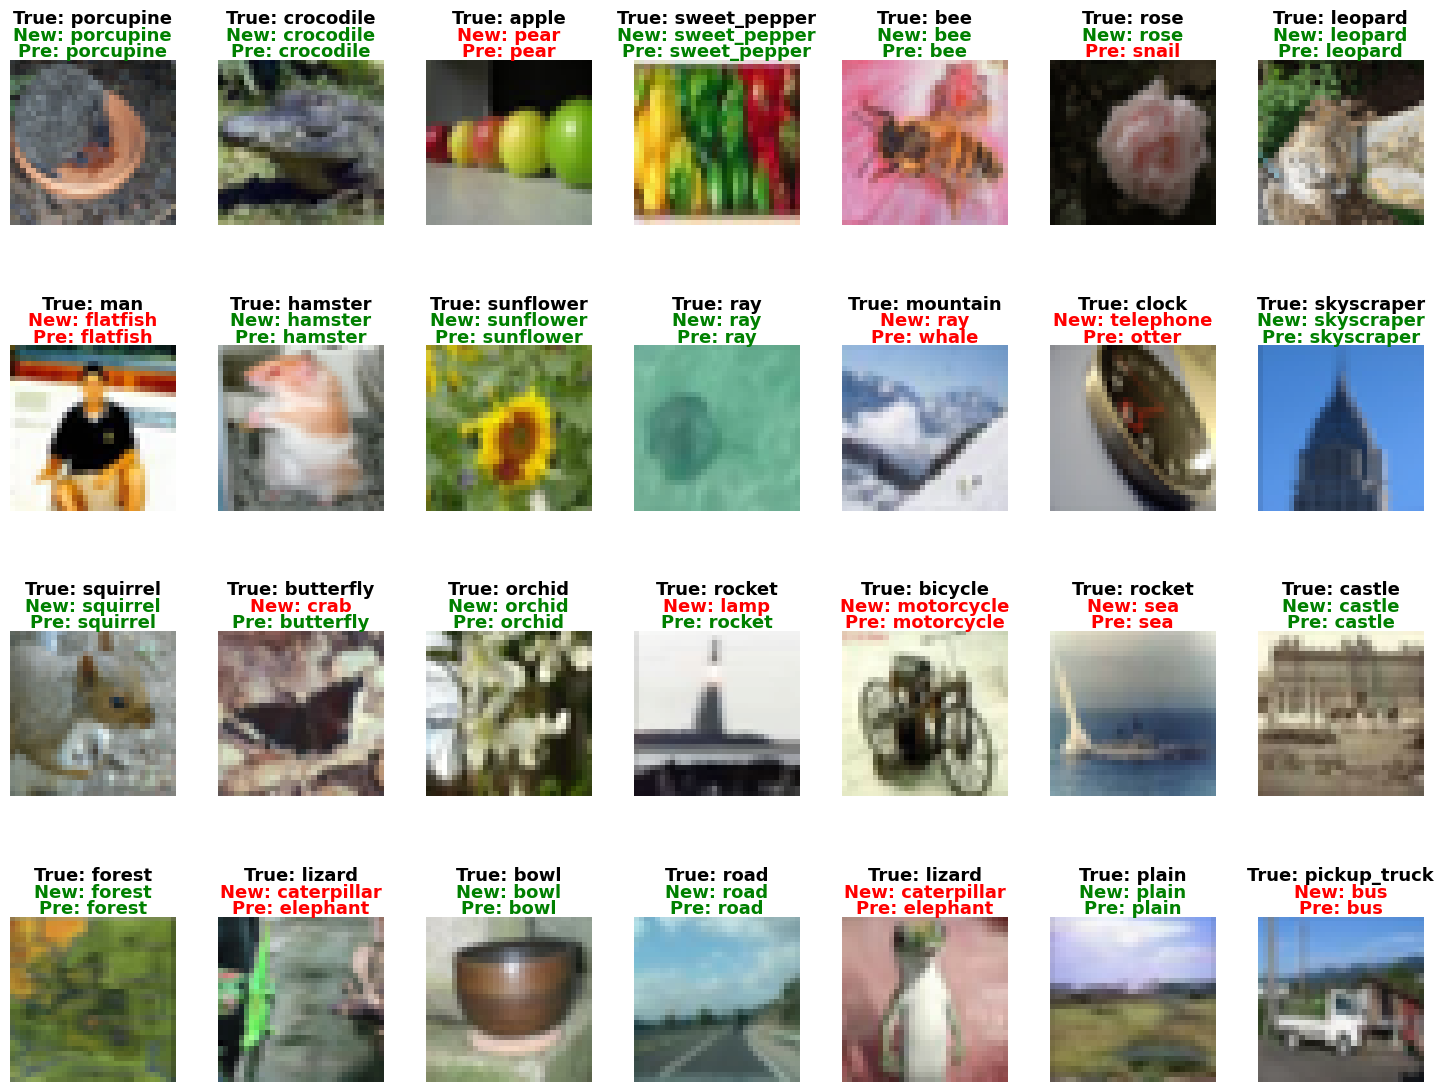

In [ ]:
visualize_images(new_resnet_model, pre_trained_resnet, 'New', 'Pre', testset_100, CLASS_NAMES_C100, norm_mean_100, norm_std_100, s=43)

## **Closing This Chapter**

In this chapter, we explored the **importance of depth** in convolutional neural networks.  
We walked through two of the most groundbreaking architectures in the history of ML:  

- **AlexNet** — the model that proved the raw power of deep networks and ended the era of hand-crafted features.  
- **ResNet** — the revolutionary design that overcame the vanishing gradient problem with **residual blocks**, opening the doors to training networks with hundreds of layers.  

Finally, we saw how **Transfer Learning** allows models to carry forward the knowledge they have already built—making training faster, more efficient, and sometimes the only way to tackle problems with limited data.  

These milestones show us that progress in deep learning doesn’t come from brute force alone—it comes from **elegant ideas** that change how we think about learning itself.  

---

### **What's Next?**

> **Autoencoders**

Unlike classifiers that only tell us *what* an image is, these networks learn to **rebuild the image itself**. By forcing a model to compress information into a hidden code and then reconstruct the original input, we’ll see how neural networks can discover the most essential patterns hidden within data.  

They are the foundation of powerful ideas like **dimensionality reduction, anomaly detection, image denoising, and even generative models**. In the next chapter, we’ll open the door to this fascinating world where neural networks don’t just recognize data — they *understand* and *recreate* it.  



##**Resources**
>[Sharifi Zarchi - Introduction to Machine Learning](https://github.com/SharifiZarchi/Introduction_to_Machine_Learning/tree/main/Jupyter_Notebooks/Chapter_04_Computer_Vision)